# Cross-modality brain panel transfer to RIBOMap

This notebook follows the biological workflow from real input data to a trained model, a newly selected panel, and manuscript-matched biological analyses. It does not read packaged aggregate results as tutorial inputs. [Open the editable source notebook on GitHub](https://github.com/fym0503/SMITH/blob/main/docs/source/tutorials/notebooks/ribomap_section/03_SMITH_RIBOMap_Transfer_source.ipynb).

## Biological question

Can a compact gene panel transfer cell-type and brain-region biology from reference modalities into RIBOMap? Deep-RIBOmap and STARmap measure related but non-identical molecular views, so the biological question is whether the same panel captures stable tissue structure without erasing ribosome-associated expression differences.

**How to read the endpoint:** Cell-type and region accuracy test whether the panel transfers biological identity and anatomy. Same- versus cross-modality Jaccard measures which biological features are stable across references. RIBOMap bias tests whether panel membership follows translatome-specific abundance rather than only generic expression.

## Step 0: Download the real input data

Download the versioned Zenodo archive and verify its checksums before training:

```bash
python scripts/download_tutorial_data.py \
  --case 03_ribomap_transfer \
  --data-root data/tutorials
```

The notebook is pre-executed for documentation. Read the Docs does not download large data or train SMITH during documentation builds.

## Configuration

In [1]:
from pathlib import Path
import hashlib, json, os, subprocess, sys
from IPython.display import Image, Markdown, display

def find_repository(start):
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "reproducibility").exists():
            return candidate
    raise RuntimeError("Run this notebook inside a SMITH repository checkout.")

ROOT = find_repository(Path.cwd().resolve())
DATA_ROOT = Path(os.environ.get("SMITH_TUTORIAL_DATA", "data/tutorials")).expanduser().resolve()
OUTPUT_ROOT = Path(os.environ.get("SMITH_TUTORIAL_OUTPUT", "outputs/tutorials")).expanduser().resolve()
CASE_OUTPUT = OUTPUT_ROOT / 'ribomap'
EPOCHS = int(os.environ.get("SMITH_TUTORIAL_EPOCHS", 3))
DEVICE = os.environ.get("SMITH_TUTORIAL_DEVICE", 'cuda:1')

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


## Step 1: Inspect the biological input data

The workflow starts from real Deep-RIBOmap, STARmap, and target RIBOMap H5AD files. Shared-gene preparation defines the common biological measurement space; target cell-type and region labels provide held-out transfer endpoints, while expression means support the RIBOMap-bias analysis.

In [2]:
inputs = ['ribomap_transfer/ribomap/deep_brain_ribomap.h5ad', 'ribomap_transfer/ribomap/mouse_brain_starmap_rep2.h5ad', 'ribomap_transfer/ribomap/mouse_brain_ribomap_rep2.h5ad']
input_checksums = {}
for relative in inputs:
    path = DATA_ROOT / relative
    if not path.is_file():
        raise FileNotFoundError(f"Missing {path}. Run scripts/download_tutorial_data.py first.")
    input_checksums[relative] = sha256_file(path)


## Step 2: Train SMITH and select a panel

For each source modality, SMITH is trained from the shared-gene H5AD with reconstruction and cell-type objectives, plus spatial coordination when coordinates are available. The ranking is converted into new source panels and evaluated on the target RIBOMap cells.

The command below starts from the H5AD inputs above and writes a fresh model ranking, panel, evaluation, and run manifest.

In [3]:
command = [sys.executable, str(ROOT / 'reproducibility/workflows/ribomap_transfer/run_tutorial.py'), "--data-root", str(DATA_ROOT), "--output-dir", str(CASE_OUTPUT), "--device", DEVICE, "--epochs", str(EPOCHS)] + ['--methods', 'SMITH', '--panel-sizes', '32,64,128', '--training-seeds', '1,2', '--evaluation-seeds', '1,2,3', '--max-cells', '3000'] + ["--force"]
completed = subprocess.run(command, cwd=ROOT, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
if completed.returncode:
    print(completed.stdout)
    raise subprocess.CalledProcessError(completed.returncode, command)
manifest = json.loads((CASE_OUTPUT / "run_manifest.json").read_text())
if not manifest.get("training_runs"):
    raise RuntimeError("The workflow did not record any SMITH training runs.")
for relative in ['figure_data/figure4_c_f_values.tsv', 'figure_data/figure4_g_jaccard.tsv', 'figure_data/figure4_h_ribomap_bias.tsv', 'figure_data/figure4_h_pairwise_tests.tsv']:
    if not (CASE_OUTPUT / relative).is_file():
        raise FileNotFoundError(CASE_OUTPUT / relative)


## Step 3: Evaluate held-out biology

Cell-type and region accuracy test whether the panel transfers biological identity and anatomy. Same- versus cross-modality Jaccard measures which biological features are stable across references. RIBOMap bias tests whether panel membership follows translatome-specific abundance rather than only generic expression.

The next cell recomputes one held-out prediction from the newly selected panel and writes truth/prediction files. The workflow also records split-level metrics and statistical metadata. No aggregate reference output is read.

In [4]:
from reproducibility.workflows.ribomap_transfer.analysis import write_statistical_analysis
from reproducibility.workflows.ribomap_transfer.evaluate_outputs import evaluate_panel

panel_file = CASE_OUTPUT / "runs/Deep-RIBOmap/seed_1/panels/SMITH_top32.tsv"
recheck_dir = CASE_OUTPUT / "notebook_recheck" / "Deep-RIBOmap_celltype"
evaluate_panel(
    DATA_ROOT / "ribomap_transfer/ribomap/mouse_brain_ribomap_rep2.h5ad",
    panel_file, 32, 1, "celltype", recheck_dir, 5,
)
write_statistical_analysis(
    CASE_OUTPUT / "figure_data/figure4_c_f_values.tsv",
    CASE_OUTPUT / "figure_data/figure4_h_ribomap_bias.tsv",
    CASE_OUTPUT / "figure_data",
)
if not (recheck_dir / "predictions.tsv").is_file():
    raise FileNotFoundError("Held-out RIBOMap predictions were not generated")


## Step 4: Render the manuscript panels

Only the manuscript figure images are rendered below. Intermediate tables and logs remain in the output directory but are not displayed.

### Figure 4c - Deep-RIBOmap cell-type transfer

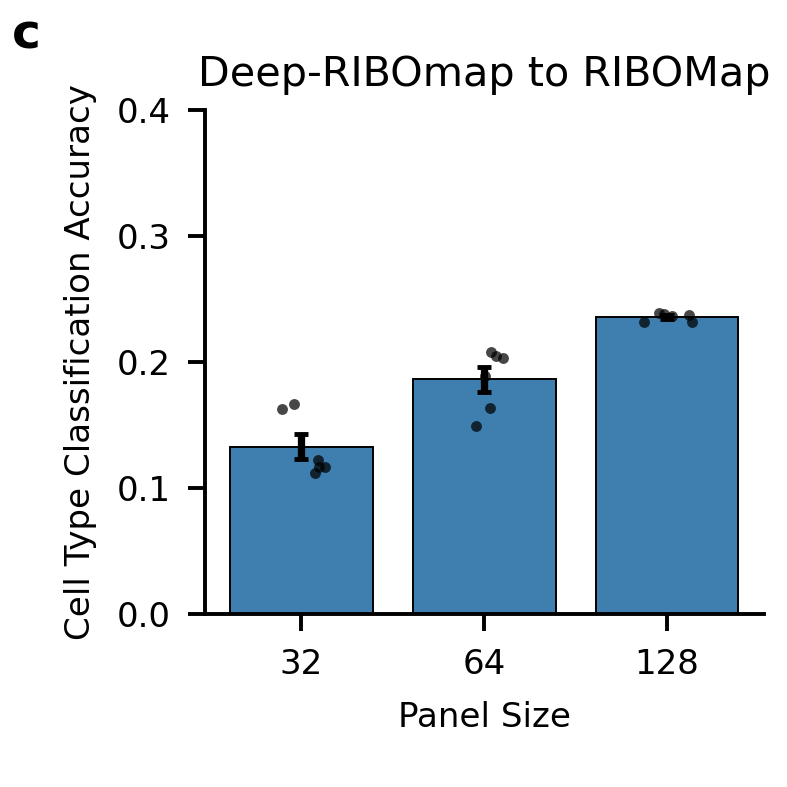

### Figure 4d - Deep-RIBOmap region transfer

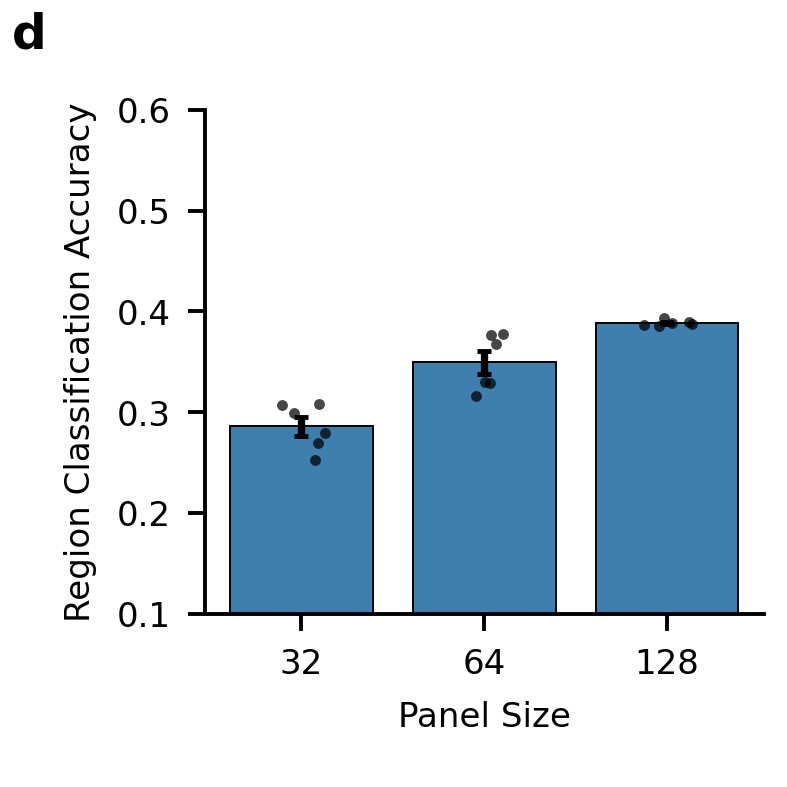

### Figure 4e - STARmap cell-type transfer

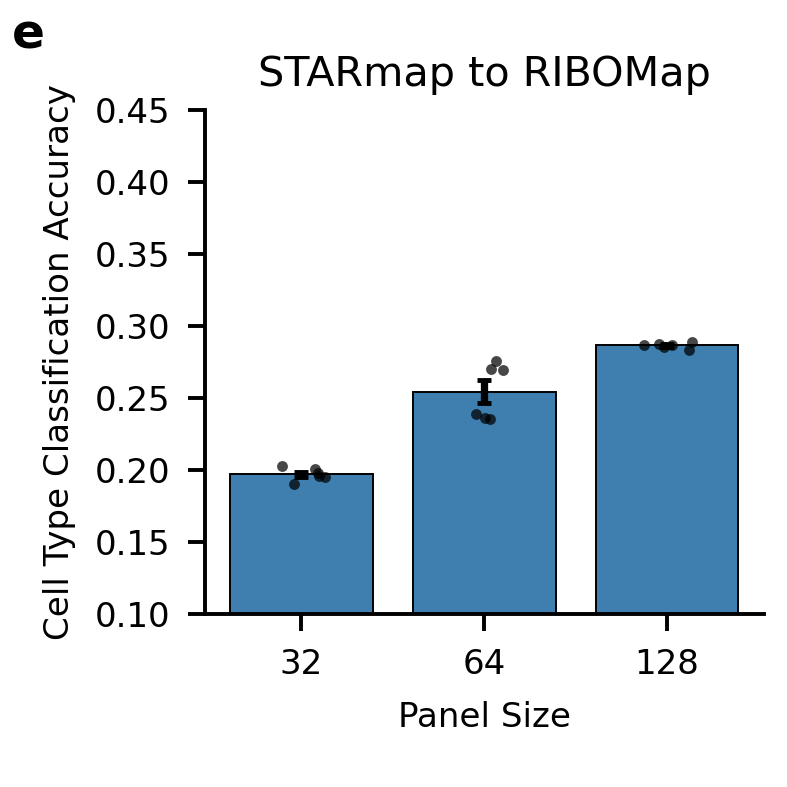

### Figure 4f - STARmap region transfer

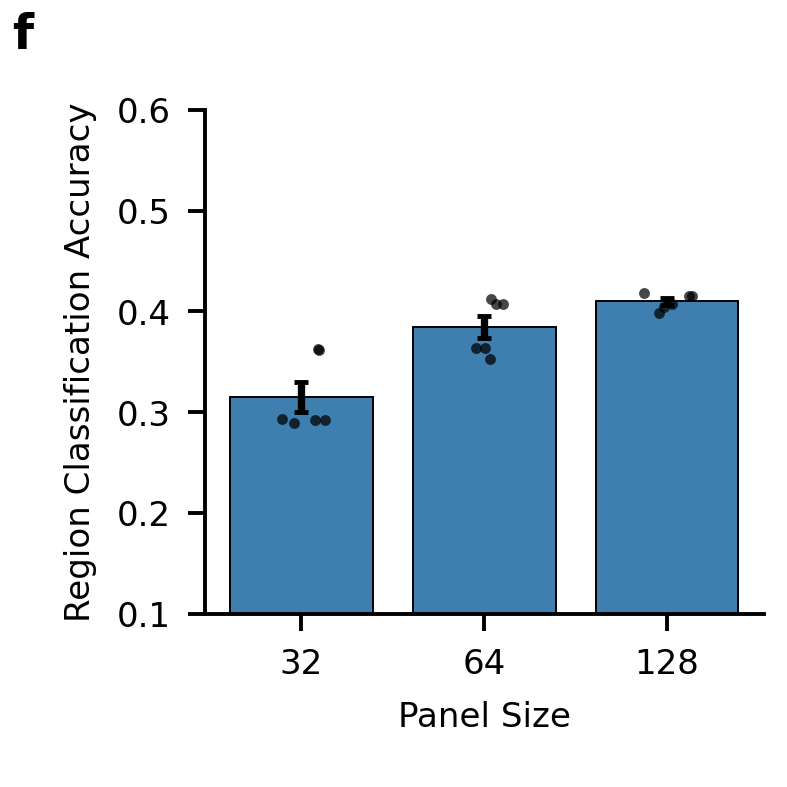

### Figure 4g - same- versus cross-modality overlap

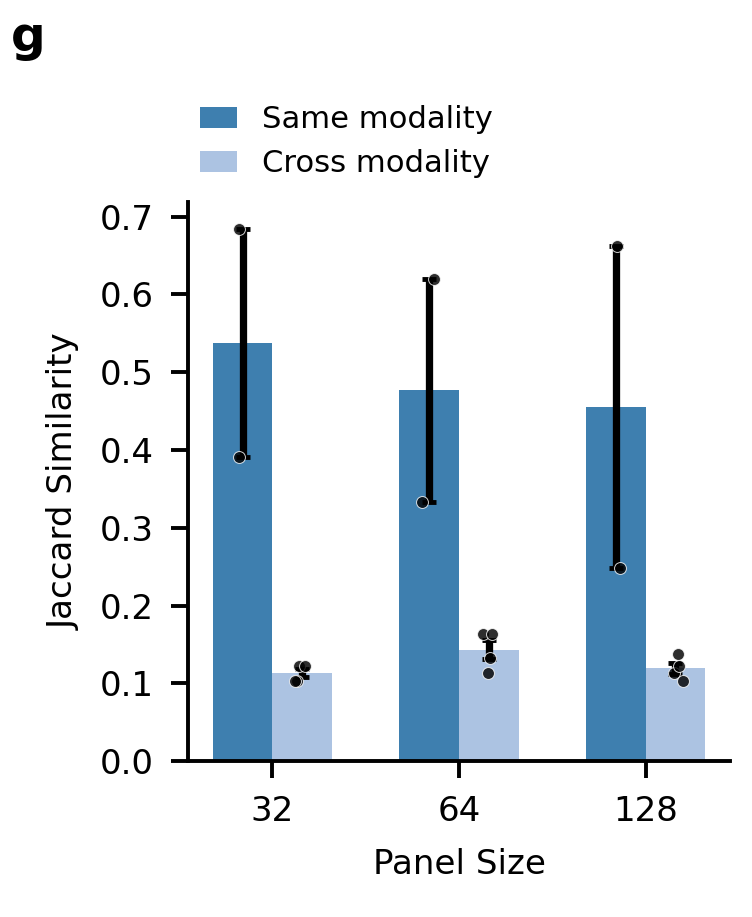

### Figure 4h - RIBOMap expression bias

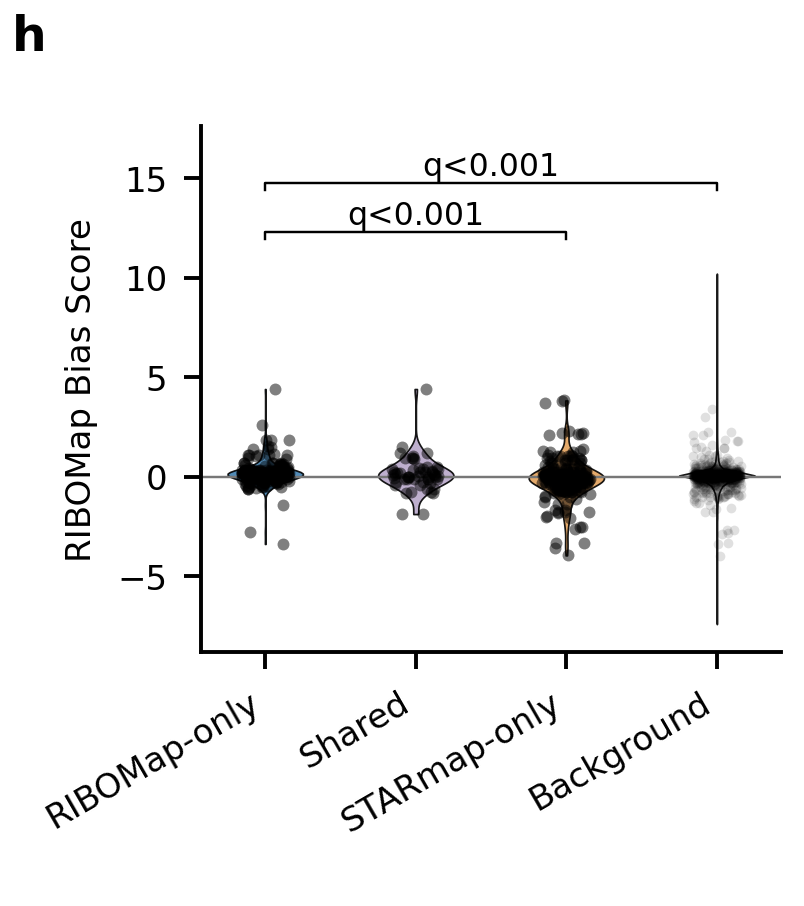

### Shared method legend

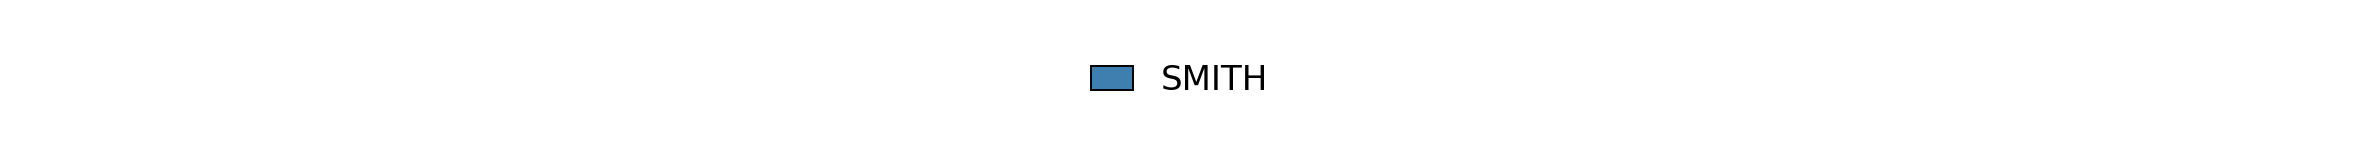

In [5]:
figure_dir = CASE_OUTPUT / "figures"
plot_command = [sys.executable, str(ROOT / 'reproducibility/workflows/ribomap_transfer/plot_figure4.py'), '--metrics', str(CASE_OUTPUT / 'figure_data/figure4_c_f_values.tsv'), '--overlap', str(CASE_OUTPUT / 'figure_data/figure4_g_jaccard.tsv'), '--bias', str(CASE_OUTPUT / 'figure_data/figure4_h_ribomap_bias.tsv'), '--bias-tests', str(CASE_OUTPUT / 'figure_data/figure4_h_pairwise_tests.tsv'), "--output-dir", str(figure_dir)]
subprocess.run(plot_command, cwd=ROOT, check=True, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
for heading, relative, width in [('Figure 4c - Deep-RIBOmap cell-type transfer', 'figures/figure4_c.png', 430), ('Figure 4d - Deep-RIBOmap region transfer', 'figures/figure4_d.png', 430), ('Figure 4e - STARmap cell-type transfer', 'figures/figure4_e.png', 430), ('Figure 4f - STARmap region transfer', 'figures/figure4_f.png', 430), ('Figure 4g - same- versus cross-modality overlap', 'figures/figure4_g.png', 430), ('Figure 4h - RIBOMap expression bias', 'figures/figure4_h.png', 430), ('Shared method legend', 'figures/figure4_method_legend.png', 900)]:
    display(Markdown(f"### {heading}"))
    display(Image(filename=str(CASE_OUTPUT / relative), width=width))


## Full manuscript command

Append the following paper-scale arguments to the workflow command:

```text
--methods SMITH,PERSIST-class,PERSIST,ActiveSVM,scGIST,scGeneFit,Spapros --baseline-root external/SMITH_baselines/GPS_tools-main/baselines --baseline-python PERSIST=/opt/envs/persist/bin/python --baseline-python PERSIST-class=/opt/envs/persist/bin/python --baseline-python scGIST=/opt/envs/scgist/bin/python --panel-sizes 32,64,128 --training-seeds 1,2,3,4,5 --evaluation-seeds 1,2,3,4,5 --epochs 200
```

The workflow tests whether a panel selected in related brain modalities preserves cell-type and region biology in RIBOMap. Figure 4c-h provide the manuscript-aligned visual summaries. Figure 4i is deliberately omitted unless a versioned Reactome/GO snapshot is supplied. Figure 4j-n additionally require the manuscript clean-fusion aligned H5AD and are not replaced with unrelated summaries. This quick hosted run is intentionally smaller than the paper-scale comparison, but it starts from the same real inputs and executes the same prediction and analysis functions.